In [1]:
import sys
from pathlib import Path

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import os
os.chdir(project_root)

In [2]:
import torch
import numpy as np
import yaml
from torch.utils.data import DataLoader

from src.data.pipeline import get_datasets
from src.models.transformer_model import StockTransformer
from src.simulation.engine import BacktestEngine
from src.simulation.metrics import compute_metrics
from src.utils.config import load_config

In [3]:
config = load_config()

# Use same project root as load_config() so path works regardless of cwd
from src.utils import config as _cfg
config_path = _cfg.PROJECT_ROOT / "configs" / "default_config.yaml"
with config_path.open("r", encoding="utf-8") as f:
    raw_cfg = yaml.safe_load(f)
sim = raw_cfg.get("simulation", {})

initial_capital = float(sim.get("initial_capital", 100_000))
position_size_pct = float(sim.get("position_size_pct", 1.0))
entry_threshold_pct = float(sim.get("entry_threshold_pct", 0.5))
exit_threshold_pct = float(sim.get("exit_threshold_pct", -0.5))
commission_pct = float(sim.get("commission_pct", 0.1))
risk_free_rate_annual = float(sim.get("risk_free_rate_annual", 0.03))

print("Simulation config:", initial_capital, position_size_pct, entry_threshold_pct, exit_threshold_pct, commission_pct)

Simulation config: 100000.0 0.3 0.5 -5.0 0.1


In [4]:
from src.data.pipeline import extract_dataset
from src.data.dataset import time_series_split
from src.utils.config import split_per_symbol

_, _, test_dataset, feature_columns = get_datasets(config)
print(f"Test samples: {len(test_dataset)}, features: {len(feature_columns)}")
print(f"Target: {config.data.target_column}, split: {config.data.split_mode}")

df_all, _ = extract_dataset(config)
_, _, test_df = time_series_split(
    df_all,
    train_split=config.data.train_split,
    val_split=config.data.val_split,
    test_split=config.data.test_split,
    per_symbol=split_per_symbol(config),
)

price_col = config.data.price_column
target_col = config.data.target_column
date_col = "date"
symbol_col = "symbol"

sort_cols = [symbol_col, date_col] if symbol_col in test_df.columns else [date_col]
test_df = test_df.sort_values(sort_cols).reset_index(drop=True)

if symbol_col in test_df.columns:
    print(f"Tickers in test set: {sorted(test_df[symbol_col].unique())}")
    print(f"Test rows: {len(test_df)}")
    print(f"Rows per ticker: {test_df.groupby(symbol_col).size().to_dict()}")

Test samples: 1854, features: 34
Target: log_return, split: per_symbol
Tickers in test set: ['AAPL', 'AMZN', 'BAC', 'COST', 'CVX', 'GOOGL', 'JNJ', 'JPM', 'KO', 'MA', 'MSFT', 'NFLX']
Test rows: 2574
Rows per ticker: {'AAPL': 215, 'AMZN': 201, 'BAC': 196, 'COST': 218, 'CVX': 218, 'GOOGL': 218, 'JNJ': 218, 'JPM': 218, 'KO': 218, 'MA': 218, 'MSFT': 218, 'NFLX': 218}


In [5]:
# Use project root + config checkpoint filename (set paths.checkpoint_file in config for correct model)
checkpoint_name = getattr(config.paths, "checkpoint_file", "best_model.pt")
checkpoint_path = _cfg.PROJECT_ROOT / config.paths.models_dir / checkpoint_name
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}. Train with 01_train_model.ipynb or set paths.checkpoint_file in config.")
import time
mtime = time.ctime(checkpoint_path.stat().st_mtime)
checkpoint = torch.load(checkpoint_path, map_location="cpu")
state_dict = checkpoint["model_state_dict"]
print(f"Loaded: {checkpoint_path.name} (modified {mtime})")
print(f"Checkpoint: epoch {checkpoint.get('epoch', '?') + 1}, val loss {checkpoint.get('score', '?'):.6f}")

# Ensure feature_columns is defined (from cell 3)
if 'feature_columns' not in globals():
    print("Warning: feature_columns not found, loading datasets...")
    _, _, _, feature_columns = get_datasets(config)

input_dim_checkpoint = state_dict["input_projection.weight"].shape[1]
input_dim_current = len(feature_columns)
d_model = state_dict["input_projection.weight"].shape[0]
n_layers = len([k for k in state_dict if "encoder.layers" in k and "self_attention.w_q.weight" in k])
n_heads = config.model.n_heads
d_ff = state_dict["encoder.layers.0.feed_forward.linear1.weight"].shape[0]

if input_dim_checkpoint != input_dim_current:
    model = StockTransformer(
        input_dim=input_dim_current,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=config.model.dropout,
        activation=config.model.activation,
        prediction_horizon=config.data.prediction_horizon,
    )
    model_dict = model.state_dict()
    compatible_dict = {k: v for k, v in state_dict.items()
                      if k in model_dict and model_dict[k].shape == v.shape}
    model_dict.update(compatible_dict)
    model.load_state_dict(model_dict, strict=False)
    print(f"Loaded {len(compatible_dict)}/{len(state_dict)} params (input_dim mismatch: using current features)")
else:
    model = StockTransformer(
        input_dim=input_dim_checkpoint,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=config.model.dropout,
        activation=config.model.activation,
        prediction_horizon=config.data.prediction_horizon,
    )
    model.load_state_dict(state_dict)
    print("Model loaded.")
model.eval()

Loaded: best_model_base.pt (modified Thu May 28 14:09:11 2026)
Checkpoint: epoch 18, val loss 0.000110
Model loaded.


StockTransformer(
  (input_projection): Linear(in_features=34, out_features=256, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attention): MultiHeadAttention(
          (w_q): Linear(in_features=256, out_features=256, bias=True)
          (w_k): Linear(in_features=256, out_features=256, bias=True)
          (w_v): Linear(in_features=256, out_features=256, bias=True)
          (w_o): Linear(in_features=256, out_features=256, bias=True)
          (attention): ScaledDotProductAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): FeedForward(
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (dropout): Dropout(p=

In [6]:
import pandas as pd
from src.data.dataset import create_sequences
from src.simulation.rules import signal_from_return_band

# Trading mode:
#   "band"  - per-ticker quantile thresholds on prediction distribution (active trading)
#   "fixed" - absolute log-return thresholds from config (effectively buy & hold for biased models)
trading_mode = "band"
entry_quantile = 0.70   # buy when prediction is in top 30% for that ticker
exit_quantile = 0.30    # sell when prediction drops to bottom 30%

ctx = config.data.context_length
print(f"Trading mode: {trading_mode}")
if trading_mode == "band":
    print(f"Entry quantile: {entry_quantile}, exit quantile: {exit_quantile}")
print("Running per-ticker backtests...")

engine = BacktestEngine(
    initial_capital=initial_capital,
    position_size_pct=position_size_pct,
    entry_threshold_pct=entry_threshold_pct,
    exit_threshold_pct=exit_threshold_pct,
    commission_pct=commission_pct,
)

per_ticker_results = {}
summary_rows = []

for ticker, group in test_df.groupby(symbol_col):
    group = group.sort_values(date_col).reset_index(drop=True)
    if len(group) < ctx + config.data.prediction_horizon + 1:
        print(f"Skipping {ticker}: not enough rows ({len(group)})")
        continue

    stacked = np.column_stack([
        group[feature_columns].values,
        group[target_col].values.reshape(-1, 1),
    ])
    seq_X, seq_y = create_sequences(stacked, ctx, config.data.prediction_horizon)
    if len(seq_X) == 0:
        print(f"Skipping {ticker}: no sequences")
        continue

    X = seq_X[:, :, :-1]
    if config.data.prediction_horizon > 1:
        actual_returns_ticker = seq_y[:, :, -1].reshape(len(seq_X), -1)[:, -1]
    else:
        actual_returns_ticker = seq_y[:, -1, -1]

    # target row starts after the context window; use that real close as the trading price.
    prices_ticker = group[price_col].values[ctx : ctx + len(seq_X)]
    dates_ticker = group[date_col].values[ctx : ctx + len(seq_X)]

    pred_batches = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(X), config.training.batch_size):
            batch_x = torch.FloatTensor(X[start : start + config.training.batch_size])
            pred = model(batch_x)
            pred_batches.append(pred.detach().cpu())
    predicted_returns_ticker = torch.cat(pred_batches).numpy().reshape(-1)

    if trading_mode == "band":
        entry_thr = float(np.quantile(predicted_returns_ticker, entry_quantile))
        exit_thr = float(np.quantile(predicted_returns_ticker, exit_quantile))
        signal_mode = "band"
    else:
        entry_thr = float(sim.get("entry_threshold_return", 0.005))
        exit_thr = float(sim.get("exit_threshold_return", -0.005))
        signal_mode = "default"

    buy_signals = [
        signal_from_return_band(p, False, entry_thr, exit_thr)
        for p in predicted_returns_ticker
    ]
    n_buy_days = sum(1 for s in buy_signals if s == "buy")

    if target_col == "log_return":
        result_ticker = engine.run_from_log_returns(
            prices=prices_ticker,
            predicted_returns=predicted_returns_ticker,
            dates=dates_ticker,
            entry_threshold=entry_thr,
            exit_threshold=exit_thr,
            signal_mode=signal_mode,
        )
    else:
        result_ticker = engine.run(prices=prices_ticker, predictions=predicted_returns_ticker)

    metrics_ticker = compute_metrics(
        result_ticker,
        initial_capital=initial_capital,
        risk_free_rate_annual=risk_free_rate_annual,
        prices=prices_ticker,
    )

    directional_accuracy = float(
        np.mean(np.sign(predicted_returns_ticker) == np.sign(actual_returns_ticker))
    )

    per_ticker_results[ticker] = {
        "result": result_ticker,
        "metrics": metrics_ticker,
        "prices": prices_ticker,
        "dates": dates_ticker,
        "predicted_returns": predicted_returns_ticker,
        "actual_returns": actual_returns_ticker,
        "entry_thr": entry_thr,
        "exit_thr": exit_thr,
    }

    summary_rows.append({
        "ticker": ticker,
        "days": len(prices_ticker),
        "entry_thr": entry_thr,
        "exit_thr": exit_thr,
        "buy_signal_pct": 100 * n_buy_days / len(prices_ticker),
        "directional_accuracy_pct": 100 * directional_accuracy,
        "strategy_return_pct": metrics_ticker.total_return_pct,
        "buy_hold_return_pct": metrics_ticker.buy_and_hold_return_pct,
        "excess_vs_bh_pct": metrics_ticker.excess_return_vs_bh_pct,
        "max_drawdown_pct": metrics_ticker.max_drawdown_pct,
        "sharpe": metrics_ticker.sharpe_ratio_annual,
        "trades": metrics_ticker.num_trades,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("excess_vs_bh_pct", ascending=False)

print("=" * 90)
print("PER-TICKER BACKTEST SUMMARY")
print("=" * 90)
display(summary_df.style.format({
    "entry_thr": "{:+.5f}",
    "exit_thr": "{:+.5f}",
    "buy_signal_pct": "{:.1f}%",
    "directional_accuracy_pct": "{:.1f}%",
    "strategy_return_pct": "{:.2f}%",
    "buy_hold_return_pct": "{:.2f}%",
    "excess_vs_bh_pct": "{:+.2f}%",
    "max_drawdown_pct": "{:.2f}%",
    "sharpe": "{:.3f}",
}))

print("\nAggregate:")
print(f"Tickers tested:              {len(summary_df)}")
print(f"Mean strategy return:        {summary_df['strategy_return_pct'].mean():.2f}%")
print(f"Mean buy & hold return:      {summary_df['buy_hold_return_pct'].mean():.2f}%")
print(f"Mean excess vs B&H:          {summary_df['excess_vs_bh_pct'].mean():+.2f}%")
print(f"Median excess vs B&H:        {summary_df['excess_vs_bh_pct'].median():+.2f}%")
print(f"Tickers beating B&H:         {(summary_df['excess_vs_bh_pct'] > 0).sum()} / {len(summary_df)}")
print(f"Mean directional accuracy:   {summary_df['directional_accuracy_pct'].mean():.2f}%")
print(f"Mean trades per ticker:      {summary_df['trades'].mean():.1f}")
print(f"Mean buy signal frequency:   {summary_df['buy_signal_pct'].mean():.1f}%")

# Keep a representative ticker for plotting in the next cell.
plot_ticker = summary_df.iloc[0]["ticker"] if len(summary_df) else None
print(f"\nDefault plot_ticker = {plot_ticker} (best excess vs B&H)")

Trading mode: band
Entry quantile: 0.7, exit quantile: 0.3
Running per-ticker backtests...
PER-TICKER BACKTEST SUMMARY


,ticker,days,entry_thr,exit_thr,buy_signal_pct,directional_accuracy_pct,strategy_return_pct,buy_hold_return_pct,excess_vs_bh_pct,max_drawdown_pct,sharpe,trades
4,CVX,158,+0.00850,+0.00808,30.4%,48.7%,7.95%,-32.76%,+40.72%,7.01%,0.617,2
7,JPM,158,+0.00831,+0.00788,30.4%,48.1%,7.42%,-29.23%,+36.65%,7.58%,0.624,4
8,KO,158,+0.00862,+0.00829,30.4%,47.5%,3.50%,-16.27%,+19.77%,4.00%,0.350,2
9,MA,158,+0.00916,+0.00888,30.4%,53.2%,11.50%,-1.10%,+12.60%,3.09%,1.444,2
6,JNJ,158,+0.00843,+0.00823,30.4%,48.7%,6.13%,-0.08%,+6.21%,3.86%,1.021,2
5,GOOGL,158,+0.00876,+0.00856,30.4%,54.4%,-2.68%,-3.47%,+0.79%,6.98%,-0.786,7
10,MSFT,158,+0.00856,+0.00821,30.4%,55.7%,12.71%,12.71%,+0.00%,4.84%,1.334,2
3,COST,158,+0.00845,+0.00787,30.4%,51.3%,2.57%,11.12%,-8.55%,2.43%,0.257,2
2,BAC,136,+0.00846,+0.00805,30.1%,53.7%,5.58%,15.90%,-10.32%,7.52%,0.505,2
1,AMZN,141,+0.00967,+0.00946,30.5%,41.1%,1.52%,13.39%,-11.88%,4.40%,0.009,9



Aggregate:
Tickers tested:              12
Mean strategy return:        5.88%
Mean buy & hold return:      3.69%
Mean excess vs B&H:          +2.19%
Median excess vs B&H:        +0.40%
Tickers beating B&H:         7 / 12
Mean directional accuracy:   50.60%
Mean trades per ticker:      3.4
Mean buy signal frequency:   30.4%

Default plot_ticker = CVX (best excess vs B&H)


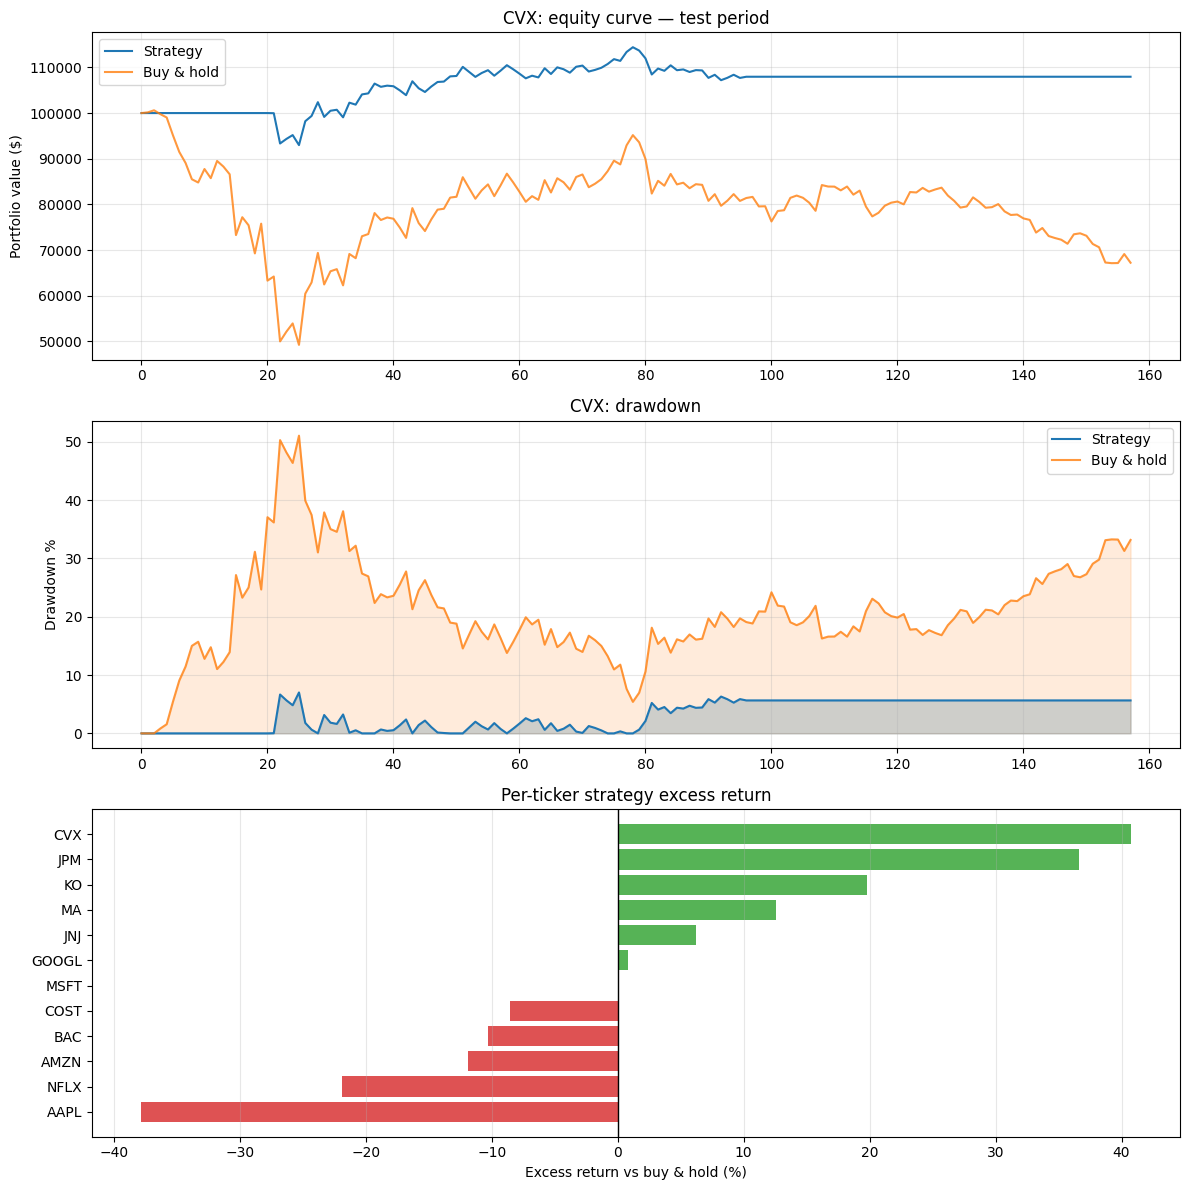

In [7]:
import matplotlib.pyplot as plt

if plot_ticker is None:
    raise ValueError("No ticker results available to plot.")

# Change this manually if you want another ticker, e.g. plot_ticker = "AAPL"
r = per_ticker_results[plot_ticker]
result = r["result"]
prices = r["prices"]

bh_shares = initial_capital / prices[0]
bh_equity = bh_shares * prices

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

def drawdown_pct(equity):
    peak = np.maximum.accumulate(equity)
    safe = np.where(peak <= 0, np.nan, peak)
    return np.nan_to_num(100 * (peak - equity) / safe, nan=0.0)

ax1 = axes[0]
ax1.plot(result.equity_curve, label="Strategy", linewidth=1.5)
ax1.plot(bh_equity, label="Buy & hold", alpha=0.8, linewidth=1.5)
ax1.set_ylabel("Portfolio value ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title(f"{plot_ticker}: equity curve — test period")

ax2 = axes[1]
x = np.arange(len(result.equity_curve))
strategy_dd = drawdown_pct(result.equity_curve)
bh_dd = drawdown_pct(bh_equity)
ax2.plot(x, strategy_dd, label="Strategy", color="C0")
ax2.fill_between(x, strategy_dd, 0, alpha=0.25, color="C0")
ax2.plot(x, bh_dd, label="Buy & hold", color="C1", alpha=0.8)
ax2.fill_between(x, bh_dd, 0, alpha=0.15, color="C1")
ax2.set_ylabel("Drawdown %")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title(f"{plot_ticker}: drawdown")

ax3 = axes[2]
plot_df = summary_df.sort_values("excess_vs_bh_pct", ascending=True)
colors = np.where(plot_df["excess_vs_bh_pct"] > 0, "C2", "C3")
ax3.barh(plot_df["ticker"], plot_df["excess_vs_bh_pct"], color=colors, alpha=0.8)
ax3.axvline(0, color="black", linewidth=1)
ax3.set_xlabel("Excess return vs buy & hold (%)")
ax3.set_title("Per-ticker strategy excess return")
ax3.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
## Конфигурация на backtest

В `configs/default_config.yaml` → секция `simulation`:

| Параметър | Значение |
|-----------|----------|
| `entry_threshold_return` | Мин. предвиден log return за **BUY** (0.005 ≈ 0.5%) |
| `exit_threshold_return` | Log return за **SELL** (напр. -0.005) |
| `position_size_pct` | Дял от капитала на сделка (0.3 = 30%) |
| `commission_pct` | Комисионна в % |

Модел: `paths.checkpoint_file` → `best_model_base.pt` (след `01_train_model`).

SyntaxError: invalid character '→' (U+2192) (3345230550.py, line 3)